### Market Regime Modeling using Hidden Markov Model (3-State Gaussian)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
import time

In [ ]:
# As before get historical data from yfinance
data = yf.download("SPY", start="2018-01-01", end="2026-01-01")
df = pd.DataFrame(index=data.index)
df["Close"] = data["Close"]
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
df["Volatility"] = df["Log_Return"].rolling(window=21).std() * np.sqrt(252)
df = df.dropna()

X_features = df[["Log_Return", "Volatility"]].values

gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
df["Regime"] = gmm.fit_predict(X_features)


[*********************100%***********************]  1 of 1 completed


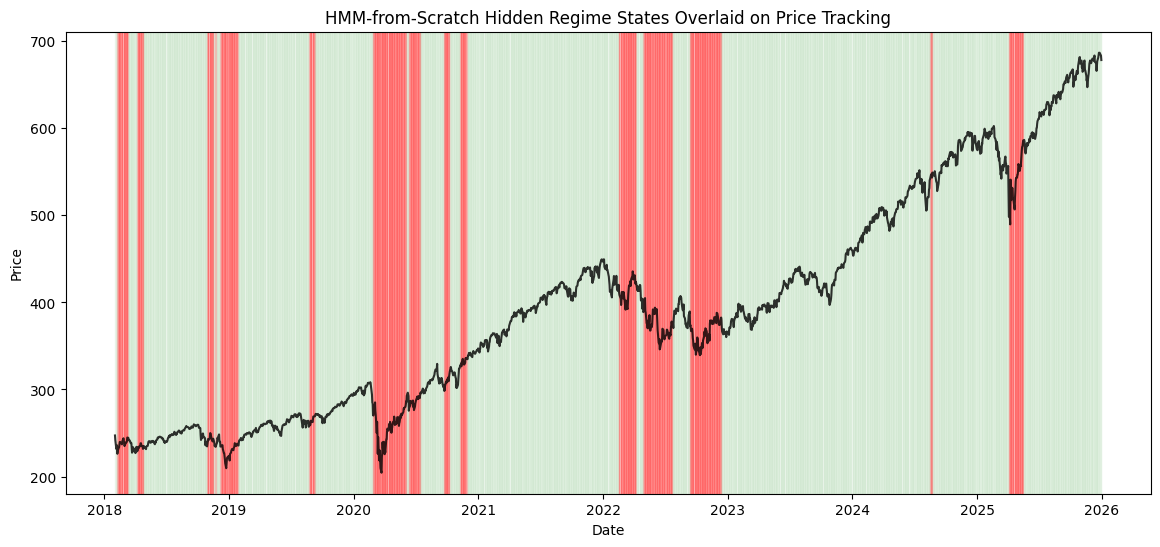

In [ ]:
# I can practice building the actual class from scratch. This may be a bit 
# I can also pursue a more black box option and look into scikit learn in the future. But for now, let's see if this makes sense. 
class SimpleGaussianHMM:

  def __init__(self, n_states=2):
    self.n_states = n_states
    self.trans_mat = np.array([[0.95, 0.05], [0.10, 0.90]])  # Sticky regimes
    self.means = np.array([0.15, 0.35])  # Mean volatility per state
    self.stds = np.array([0.03, 0.10])  # Variance per state

  def predict_states(self, volatility_series):

    states = []
    # Assume starting in calm regime
    current_prob = np.array([0.9, 0.1])

    for obs in volatility_series:
      # Calculate emission probabilities (Gaussian PDF)
      emission = (1 / (self.stds * np.sqrt(2 * np.pi))) * np.exp(
          -0.5 * ((obs - self.means) / self.stds) ** 2
      )

      # Markov transition step
      prior = current_prob @ self.trans_mat
      posterior = prior * emission

      # Normalize and choose highest probability state
      current_prob = posterior / np.sum(posterior)
      states.append(np.argmax(current_prob))

    return np.array(states)


hmm_scratch = SimpleGaussianHMM(n_states=2)
df["Regime_Scratch"] = hmm_scratch.predict_states(df["Volatility"].values)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], color="black", lw=1.5, label="SPY Price", alpha=0.8)

# Highlight background based on  state
for i in range(len(df) - 1):
    current_state = df["Regime_Scratch"].iloc[i]
    # Highlight high volatility states in light red/coral
    if current_state == 1:
        plt.axvspan(df.index[i], df.index[i+1], color="red", alpha=0.15)
    else:
        plt.axvspan(df.index[i], df.index[i+1], color="green", alpha=0.03)

plt.title("HMM Hidden Regime States Overlaid on Price Tracking")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(False) 
plt.show()

# I can also do K-means clustering but I want to keep it to a simple HMM as intended

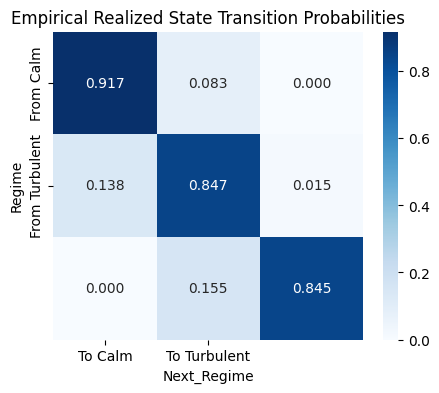

In [ ]:
# Compute empirical transition alignments
df["Next_Regime"] = df["Regime"].shift(-1)
matrix_data = pd.crosstab(df["Regime"], df["Next_Regime"], normalize="index")

plt.figure(figsize=(5, 4))
sns.heatmap(matrix_data, annot=True, cmap="Blues", fmt=".3f", 
            xticklabels=["To Calm", "To Turbulent"], 
            yticklabels=["From Calm", "From Turbulent"])
plt.title("State Transition Probabilities")
plt.show()

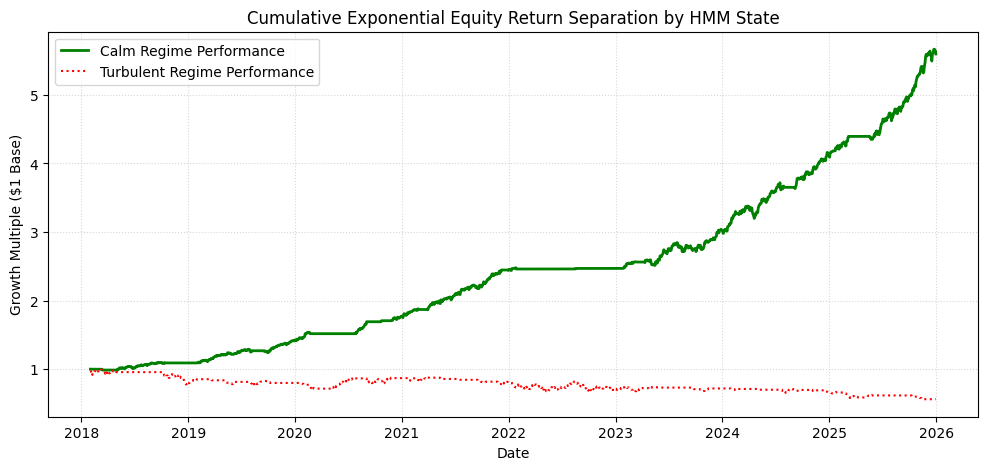

In [ ]:
df["Strategy_Return"] = df["Log_Return"]
# Filter returns based on the state assignment
df["Calm_Market_CumProd"] = df[df["Regime"] == 0]["Strategy_Return"].cumsum().apply(np.exp)
df["Turbulent_Market_CumProd"] = df[df["Regime"] == 1]["Strategy_Return"].cumsum().apply(np.exp)

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Calm_Market_CumProd"].ffill(), label="Calm Regime Performance", color="green", lw=2)
plt.plot(df.index, df["Turbulent_Market_CumProd"].ffill(), label="Turbulent Regime Performance", color="red", linestyle=":")
plt.title("Cumulative Exponential Equity Return Separation by HMM State")
plt.ylabel("Growth Multiple ($1 Base)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()